# DeepAxon v4 — Watershed QC Notebook

Visualizes watershed segmentation results for a folder of segmented images.
Calls v4 morphometrics directly — always in sync with the production pipeline.

**Columns per image row:**
- Col 1: Axon watershed labels (randomized colormap — adjacent labels visually distinct)
- Col 2: Fiber watershed labels (randomized colormap)
- Col 3: Fiber labels + matched axon centroids as dots

**Interpreting the visualization:**
- Two adjacent axons with the same color → watershed failed to separate them → one large blob
- A single axon spanning a large region with one color → over-merged watershed region
- Red dots in Col 3 → matched axon centroids. Missing dots → unmatched fibers.

In [ ]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import sys
import os
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy import ndimage as ndi

# Add repo root to path so v4 modules are accessible
# Assumes notebook lives in deepaxon/notebooks/
# Adjust the number of .parent calls if notebook is elsewhere
REPO_ROOT = Path('').resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.helpers import load_config, get_pixel_size
from utils.logger import DeepAxonLogger
from morphometrics.morphometrics import get_morphometrics

print(f'Repo root: {REPO_ROOT}')
print('v4 modules loaded successfully')

Repo root: C:\Users\mazurm\deepaxon
v4 modules loaded successfully


In [6]:
# ── Cell 2: Config + paths (edit this cell only) ─────────────────────────────

# Path to folder of segmented .tif images
SEG_FOLDER = r"T:\Orthopaedics\Lab Imaging Data\mmazur\DeepAxon\DA_v4_test\100x_study\P1501\P1501_RMND\Segmented"

# Magnification
MAG = "100X"

# Figure width per image (height scales automatically)
FIG_WIDTH = 18

# ── Derived ───────────────────────────────────────────────────────────────────
config   = load_config()
wsh_cfg  = config.get('watershed', {})
threshold = wsh_cfg.get('distance_threshold', 0.1)
disk_r    = wsh_cfg.get('dilation_disk', 5)

# Get image width from first file for pixel size lookup
seg_dir   = Path(SEG_FOLDER)
seg_files = sorted([f for f in seg_dir.iterdir()
                    if f.is_file() and f.suffix.lower() in ('.tif', '.tiff')])

if seg_files:
    sample = cv2.imread(str(seg_files[0]), cv2.IMREAD_GRAYSCALE)
    img_w  = sample.shape[1] if sample is not None else 1440
else:
    img_w  = 1440

px_size = get_pixel_size(MAG, img_w)

print(f'Segmented folder : {SEG_FOLDER}')
print(f'Magnification    : {MAG}')
print(f'Images found     : {len(seg_files)}')
print(f'Image width      : {img_w} px')
print(f'Pixel size       : {px_size} µm/px' if px_size else 'Pixel size       : ⚠ Not calibrated')
print(f'Watershed threshold: {threshold}')
print(f'Dilation disk    : {disk_r}')

Segmented folder : T:\Orthopaedics\Lab Imaging Data\mmazur\DeepAxon\DA_v4_test\100x_study\P1501\P1501_RMND\Segmented
Magnification    : 100X
Images found     : 3
Image width      : 1280 px
Pixel size       : ⚠ Not calibrated
Watershed threshold: 0.17
Dilation disk    : 5


In [7]:
def get_labels_axons(img: np.ndarray) -> np.ndarray:
    """
    Watershed segmentation using V3 threshold-based seeding.

    Foreground seeds: distance > threshold * distance.max()
      Low threshold intentional — maximizes seed count to separate
      closely packed axons. V3 validated value.
      Configurable via config.json: watershed.distance_threshold

    Background marker: dilation of mask with disk(radius)
      Configurable via config.json: watershed.dilation_disk
    """

    distance     = ndi.distance_transform_edt(img)
    sure_fg_mask = distance > threshold * distance.max()
    markers      = label(sure_fg_mask)
    sure_bg_mask = dilation(img, disk(disk_r))
    markers[sure_bg_mask == 0] = markers.max() + 1
    segmented = watershed(-distance, markers, mask=img)
    del distance, sure_fg_mask, sure_bg_mask, markers
    return segmented
  
def get_labels_fiber(
    fiber_mask: np.ndarray,
    axon_label: np.ndarray,
) -> np.ndarray:
    """
    Watershed segmentation of fiber_mask seeded from axon labels.

    Instead of deriving markers from fiber_mask's own distance transform
    (which fails when myelin sheaths touch), we transfer one seed per
    axon region from the already-labelled axon_mask.

    Foreground seeds: distance-transform peak of each axon region,
      guaranteed to land interior to the corresponding fiber region
      since axon ⊂ fiber geometrically.

    Background marker: dilation of fiber_mask with disk(5) — same
      logic as original get_labels().
    """
    disk_r = 5

    # ── 1. Extract one seed per axon at its distance-transform peak ──────────
    # Using distance peak (not centroid) so seed is maximally interior —
    # centroid can fall outside non-convex shapes
    axon_distance = ndi.distance_transform_edt(axon_label > 0)
    markers       = np.zeros_like(fiber_mask, dtype=int)

    for region in regionprops(axon_label):
        region_dist = np.where(axon_label == region.label, axon_distance, 0)
        peak        = np.unravel_index(np.argmax(region_dist), region_dist.shape)
        markers[peak] = region.label

    # ── 2. Snap any seeds that fall outside fiber_mask to nearest fg pixel ───
    # Shouldn't happen (axon ⊂ fiber) but guards against mask misalignment
    lost = (markers > 0) & (fiber_mask == 0)
    if np.any(lost):
        fg_coords   = np.array(np.where(fiber_mask > 0)).T
        lost_coords = np.array(np.where(lost)).T
        tree        = cKDTree(fg_coords)
        for coord in lost_coords:
            _, idx  = tree.query(coord)
            nearest = tuple(fg_coords[idx])
            markers[nearest]     = markers[tuple(coord)]
            markers[tuple(coord)] = 0

    # ── 3. Background marker — same as original get_labels() ─────────────────
    sure_bg              = dilation(fiber_mask, disk(disk_r))
    markers[sure_bg == 0] = markers.max() + 1

    # ── 4. Watershed on fiber_mask ────────────────────────────────────────────
    fiber_distance = ndi.distance_transform_edt(fiber_mask)
    segmented      = watershed(-fiber_distance, markers, mask=fiber_mask)

    del axon_distance, fiber_distance, sure_bg, markers
    return segmented

In [8]:
# ── Cell 3: Run v4 morphometrics + compute watershed labels ──────────────────
log = DeepAxonLogger(log_path=None, program='check_watershed')

all_dfs    = {}   # {filename: morphometrics DataFrame}
all_labels = {}   # {filename: (axon_label_array, fiber_label_array)}
all_imgs   = {}   # {filename: grayscale image array}

for f in seg_files:
    print(f'  Processing {f.name}...', end=' ')

    # Run v4 morphometrics (same function as production pipeline)
    df = get_morphometrics(str(f), MAG, log)

    # Compute watershed labels for visualization
    img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        # BGW contract: white(255)=axon, grey(128)=myelin
        axon_mask  = cv2.inRange(img, 200, 255)
        fiber_mask = cv2.inRange(img, 1, 255)
        axon_lbl   = get_labels_axons(axon_mask.astype(bool))
        fiber_lbl  = get_labels_fiber(fiber_mask.astype(bool), axon_label)
        all_labels[f.name] = (axon_lbl, fiber_lbl)
        all_imgs[f.name]   = img

    if df is not None and not df.empty:
        all_dfs[f.name] = df
        print(f'{len(df)} axons')
    else:
        all_dfs[f.name] = pd.DataFrame()
        print('no axons detected')

# Pool all results
valid_dfs = [df for df in all_dfs.values() if not df.empty]
master_df = pd.concat(valid_dfs, ignore_index=True) if valid_dfs else pd.DataFrame()
print(f'\nTotal axons: {len(master_df)}')

  Processing P1501_RMND_100X_001_segmented.tif... 

⚠  No pixel size for 100X at width 1280px — outputting pixel units only

NameError: name 'label' is not defined

In [ ]:
# ── Cell 4: Summary stats ────────────────────────────────────────────────────
if not master_df.empty:
    print(f'{"Metric":<35} {"Value"}')
    print('-' * 50)
    print(f'{"Images processed":<35} {len(all_dfs)}')
    print(f'{"Total axons":<35} {len(master_df)}')
    print(f'{"Mean axons per image":<35} {len(master_df)/len(all_dfs):.0f}')

    if 'gratio' in master_df.columns:
        print(f'{"Mean g-ratio":<35} {master_df["gratio"].mean():.4f}')
    if 'fiber_equiv_diam_um' in master_df.columns:
        print(f'{"Mean fiber diam (µm)":<35} {master_df["fiber_equiv_diam_um"].mean():.3f}')
    if 'axon_diam_um' in master_df.columns:
        print(f'{"Mean axon diam (µm)":<35} {master_df["axon_diam_um"].mean():.3f}')

    print()
    print(f'{"Image":<55} {"Axons":>6}  {"Mean g-ratio":>12}')
    print('-' * 78)
    for img_name, df in all_dfs.items():
        if df.empty:
            print(f'{img_name:<55} {"—":>6}  {"—":>12}')
        else:
            gr = f"{df['gratio'].mean():.4f}" if 'gratio' in df.columns else '—'
            print(f'{img_name:<55} {len(df):>6}  {gr:>12}')
else:
    print('⚠ No morphometric data extracted')

Metric                              Value
--------------------------------------------------
Images processed                    11
Total axons                         6029
Mean axons per image                548
Mean g-ratio                        0.6064
Mean fiber diam (µm)                5.770
Mean axon diam (µm)                 3.347

Image                                                    Axons  Mean g-ratio
------------------------------------------------------------------------------
Rb41_RA_40X_001_segmented.tif                              641        0.6061
Rb41_RA_40X_002_segmented.tif                              133        0.6059
Rb41_RA_40X_003_segmented.tif                              632        0.5909
Rb41_RA_40X_004_segmented.tif                              324        0.5761
Rb41_RA_40X_005_segmented.tif                              723        0.5979
Rb41_RA_40X_006_segmented.tif                              426        0.5980
Rb41_RA_40X_007_segmented.tif            

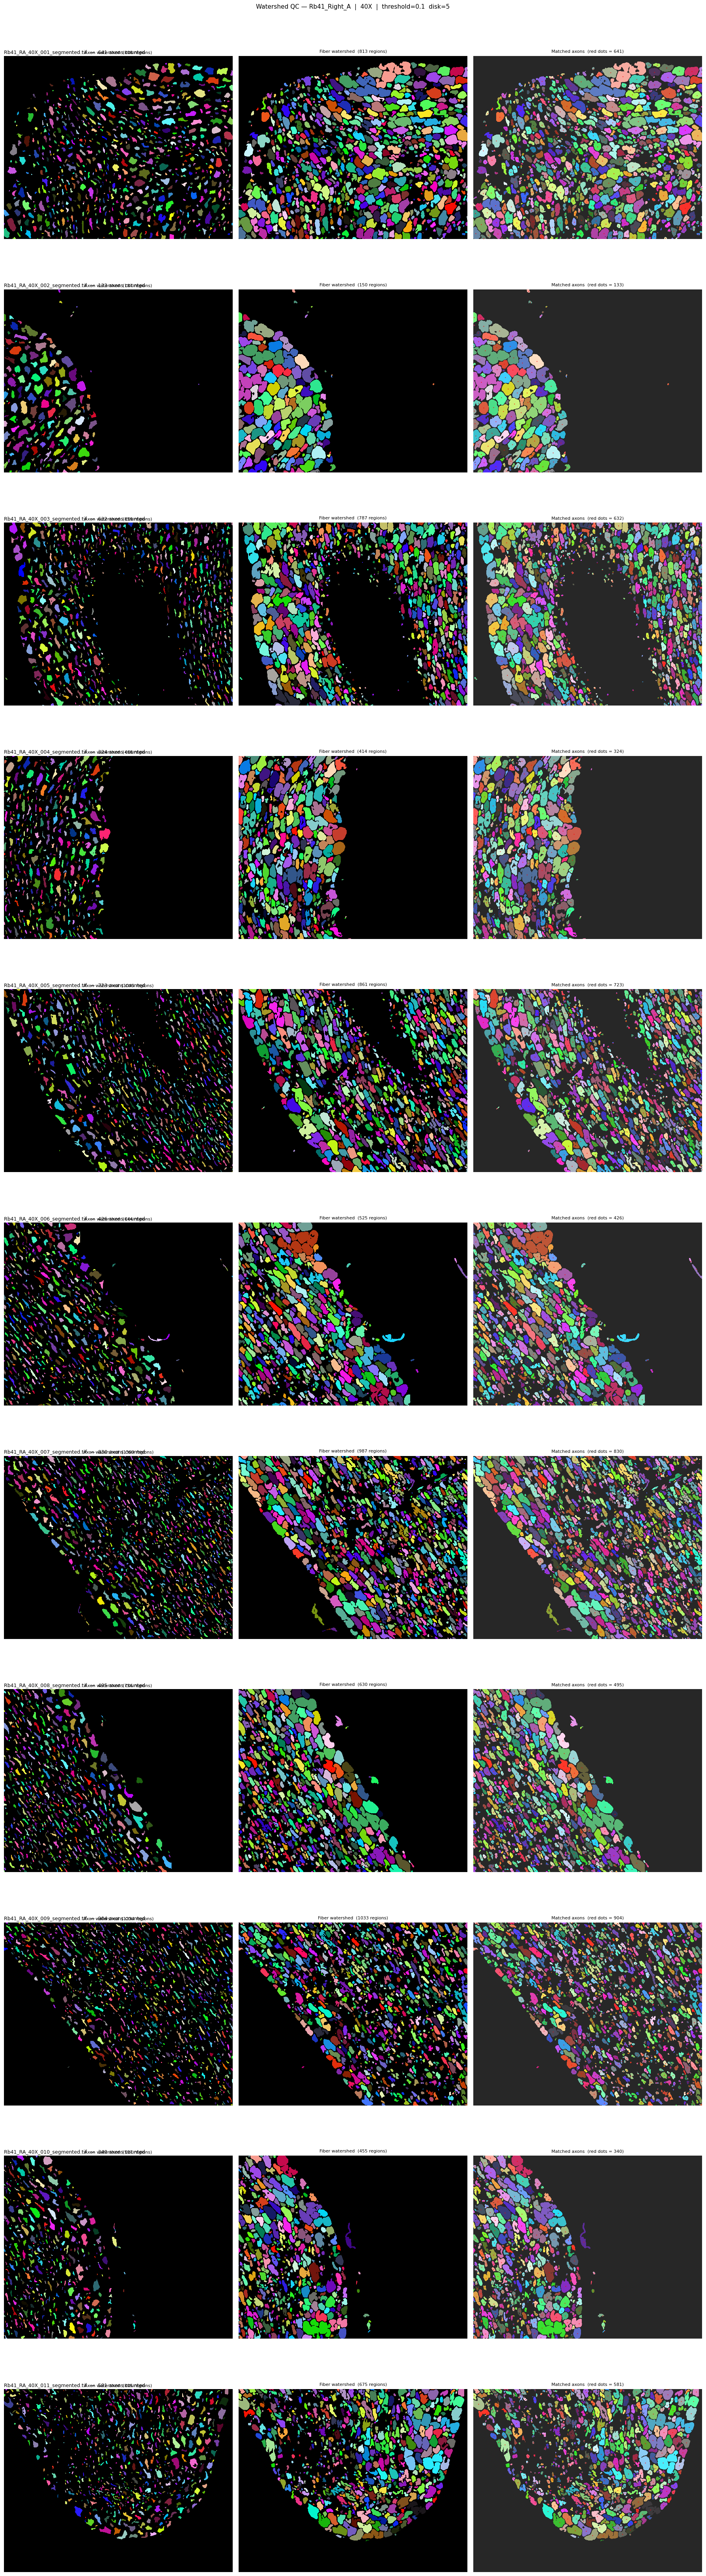

Figure saved to watershed_qc.png in nerve folder


In [ ]:
# ── Cell 5: Watershed label grid (3 × N) ─────────────────────────────────────
#
# Column 1: Axon watershed labels  — randomized colormap
# Column 2: Fiber watershed labels — randomized colormap
# Column 3: Fiber labels + matched axon centroids (red dots)
#
# Randomized colormap: adjacent label indices get visually distinct colors.
# A merged axon shows as one large same-colored blob — immediately visible.
# ─────────────────────────────────────────────────────────────────────────────

def make_random_cmap(n_labels: int, seed: int = 42) -> mcolors.ListedColormap:
    """Randomized colormap. Label 0 (background) always black."""
    rng    = np.random.default_rng(seed)
    colors = rng.random((max(n_labels + 1, 2), 3))
    colors[0] = [0, 0, 0]  # background = black
    return mcolors.ListedColormap(colors)


n_images = len(seg_files)
row_h    = FIG_WIDTH / 3  # keep panels roughly square

fig, axes = plt.subplots(
    n_images, 3,
    figsize=(FIG_WIDTH, row_h * n_images),
    squeeze=False
)

for row_idx, f in enumerate(seg_files):
    img_name              = f.name
    axon_lbl, fiber_lbl   = all_labels.get(img_name, (None, None))
    df                    = all_dfs.get(img_name, pd.DataFrame())

    ax_axon  = axes[row_idx, 0]
    ax_fiber = axes[row_idx, 1]
    ax_over  = axes[row_idx, 2]

    axon_count = len(df)
    row_title  = f"{img_name}  —  {axon_count} axons counted"

    if axon_lbl is None:
        for ax in [ax_axon, ax_fiber, ax_over]:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
            ax.axis('off')
        ax_axon.set_title(row_title, fontsize=9, loc='left', pad=4)
        continue

    # ── Column 1: Axon labels ─────────────────────────────────────────────────
    n_axon_labels = axon_lbl.max()
    ax_axon.imshow(axon_lbl, cmap=make_random_cmap(n_axon_labels), interpolation='nearest')
    ax_axon.set_title(f'Axon watershed  ({n_axon_labels} regions)', fontsize=8)
    ax_axon.axis('off')

    # ── Column 2: Fiber labels ────────────────────────────────────────────────
    n_fiber_labels = fiber_lbl.max()
    ax_fiber.imshow(fiber_lbl, cmap=make_random_cmap(n_fiber_labels, seed=99),
                    interpolation='nearest')
    ax_fiber.set_title(f'Fiber watershed  ({n_fiber_labels} regions)', fontsize=8)
    ax_fiber.axis('off')

    # ── Column 3: Fiber labels + matched axon centroids ───────────────────────
    ax_over.imshow(fiber_lbl, cmap=make_random_cmap(n_fiber_labels, seed=99),
                   interpolation='nearest', alpha=0.85)

    # Plot matched axon centroids from morphometrics output
    if not df.empty and 'x' in df.columns and 'y' in df.columns:
        ax_over.scatter(
            df['y'].values, df['x'].values,
            s=8, c='red', marker='.', linewidths=0,
            label=f'{axon_count} matched axons'
        )

    ax_over.set_title(f'Matched axons  (red dots = {axon_count})', fontsize=8)
    ax_over.axis('off')

    # Row label on left panel
    ax_axon.set_title(row_title, fontsize=9, loc='left', pad=4)

plt.suptitle(
    f'Watershed QC — {Path(SEG_FOLDER).parent.name}  |  {MAG}  |  '
    f'threshold={threshold}  disk={disk_r}',
    fontsize=11, y=1.001
)
plt.tight_layout()
plt.savefig(str(Path(SEG_FOLDER).parent / 'watershed_qc.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to watershed_qc.png in nerve folder')

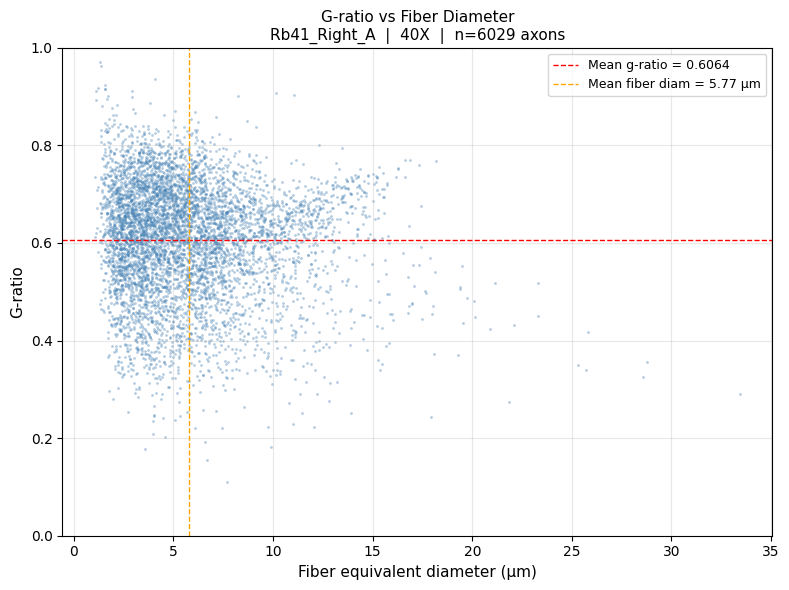

Figure saved to gratio_scatter.png in nerve folder


In [ ]:
# ── Cell 6: G-ratio vs fiber diameter scatter (all images pooled) ────────────
if not master_df.empty and 'gratio' in master_df.columns:

    diam_col  = 'fiber_equiv_diam_um' if 'fiber_equiv_diam_um' in master_df.columns else 'fiber_equiv_diam'
    diam_unit = 'µm' if 'fiber_equiv_diam_um' in master_df.columns else 'px'

    if diam_col in master_df.columns:
        fig, ax = plt.subplots(figsize=(8, 6))

        ax.scatter(
            master_df[diam_col],
            master_df['gratio'],
            s=4, alpha=0.4, color='steelblue', linewidths=0
        )

        # Mean lines
        ax.axhline(master_df['gratio'].mean(), color='red',
                   linestyle='--', linewidth=1,
                   label=f'Mean g-ratio = {master_df["gratio"].mean():.4f}')
        ax.axvline(master_df[diam_col].mean(), color='orange',
                   linestyle='--', linewidth=1,
                   label=f'Mean fiber diam = {master_df[diam_col].mean():.2f} {diam_unit}')

        ax.set_xlabel(f'Fiber equivalent diameter ({diam_unit})', fontsize=11)
        ax.set_ylabel('G-ratio', fontsize=11)
        ax.set_title(
            f'G-ratio vs Fiber Diameter\n'
            f'{Path(SEG_FOLDER).parent.name}  |  {MAG}  |  n={len(master_df)} axons',
            fontsize=11
        )
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(str(Path(SEG_FOLDER).parent / 'gratio_scatter.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()
        print('Figure saved to gratio_scatter.png in nerve folder')
    else:
        print(f'⚠ {diam_col} column not found — check pixel size calibration')
else:
    print('⚠ No g-ratio data available')